# Data Preparation Steps:

1. Data Extraction
2. Data Preprocessing (Turnaround, PPE, FOD)
3. Exploratory Data Analysis (EDA)

In [1]:
# ------------------------------------
# 1. Workspace & Path Initialization
# ------------------------------------
import sys
import yaml
from pathlib import Path

# Active workspace directory paths
BASE_DIR = Path("/teamspace/studios/this_studio/airport-incident-detection")
RAW_DIR = BASE_DIR / "data/raw"
PROCESSED_DIR = BASE_DIR / "data/processed"
CONFIG_DIR = PROCESSED_DIR / "config"

# Ensure target storage folders exists
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Connect to custom data preparation modules
SRC_DIR = str(BASE_DIR / "src")
if SRC_DIR not in sys.path:
    sys.path.append(SRC_DIR)

%reload_ext autoreload
%autoreload 2

print("🚀 Path workspace successfully connected! Modules are importable.")

🚀 Path workspace successfully connected! Modules are importable.


## Data Extraction
Task Performed:
 - Extract Airport Tarmac turnaround, PPE and FOD-A datasets from Kaggle.

In [2]:
# ------------------------------------
# 2. Run Data Extraction
# ------------------------------------
from data_preparation.data_extraction import fetch_datasets_from_kaggle
fetch_datasets_from_kaggle(RAW_DIR)


📡 Downloading raw data for airport-turnaround...
Dataset URL: https://www.kaggle.com/datasets/shazam0k/airport-turnaround-dataset
License(s): unknown


 13%|█▎        | 158M/1.15G [00:00<00:06, 169MB/s] 

100%|██████████| 1.15G/1.15G [00:10<00:00, 113MB/s] 



📦 Unpacking compressed data into airport-turnaround
🧹 Deleted the zip file of airport-turnaround for clean workspace!

📡 Downloading raw data for ppe-compliance...
Dataset URL: https://www.kaggle.com/datasets/shazam0k/airport-ppe-dataset
License(s): unknown


100%|██████████| 921M/921M [00:05<00:00, 180MB/s]  



📦 Unpacking compressed data into ppe-compliance
🧹 Deleted the zip file of ppe-compliance for clean workspace!

📡 Downloading raw data for fod-data...
Dataset URL: https://www.kaggle.com/datasets/kilogrand/foreign-object-debris-in-airports-fod-a-dataset
License(s): MIT


100%|██████████| 412M/412M [00:03<00:00, 115MB/s]  



📦 Unpacking compressed data into fod-data
🧹 Deleted the zip file of fod-data for clean workspace!

✅ Successfully extracted Kaggle Datasets.


## Data Preprocessing
Tasks performed:
 - Data Cleaning
 - Data Validation
 - Data Splitting
 - YAML config generation

In [3]:
# ------------------------------------
# 3. Process the Datasets
# Streams: Turnaround, PPE & FOD
# ------------------------------------
from data_preparation.turnaround_preprocessing import process_and_clean_turnaround
from data_preparation.ppe_preprocessing import process_and_clean_ppe
from data_preparation.fod_preprocessing import process_and_split_fod
from data_preparation.config_generator import generate_yaml_profiles

# 1. Airport Turnaround: Run custom filtering module
process_and_clean_turnaround(RAW_DIR, PROCESSED_DIR)

# 2. PPE Compliance: Run custom filtering module
process_and_clean_ppe(RAW_DIR, PROCESSED_DIR)

# 3. FOD Stream: Run XML parsing and conversion module
fod_class_list = process_and_split_fod(RAW_DIR, PROCESSED_DIR)

# 4. Configurations: Write out unified YAML configuration profiles
generate_yaml_profiles(PROCESSED_DIR, fod_class_list)

🚚 Isolating and migrating clean Airport Turnaround splits...


✅ Turnaround Stream completely standardized for YOLO training.

🧹 Extracting and re-indexing the 4 target PPE compliance classes...
✅ Successfully isolated 11306 custom filtered files for the PPE Stream!

⌛ Translating FOD Pascal-VOC XML arrays into clean YOLO files...
✂️ Distributing structured assets into target partitions...
✅ Generated FOD split. Total valid records migrated: 33793

📝 Master configurations written successfully to: /teamspace/studios/this_studio/airport-incident-detection/data/processed/config


## Exploratory Data Analysis
Output Consists of:
 - Dataset Summary
 - Object count plot
 - In-depth insights

📊 STARTING IN-DEPTH EDA FOR AIRPORT APRON TURNAROUND STREAM

📈 DATASET SPLIT INFRASTRUCTURE PROFILE:
Split  Image Count  Total Bounding Boxes
Train         8192                 47742
  Val         1050                  5951
 Test          498                  2785


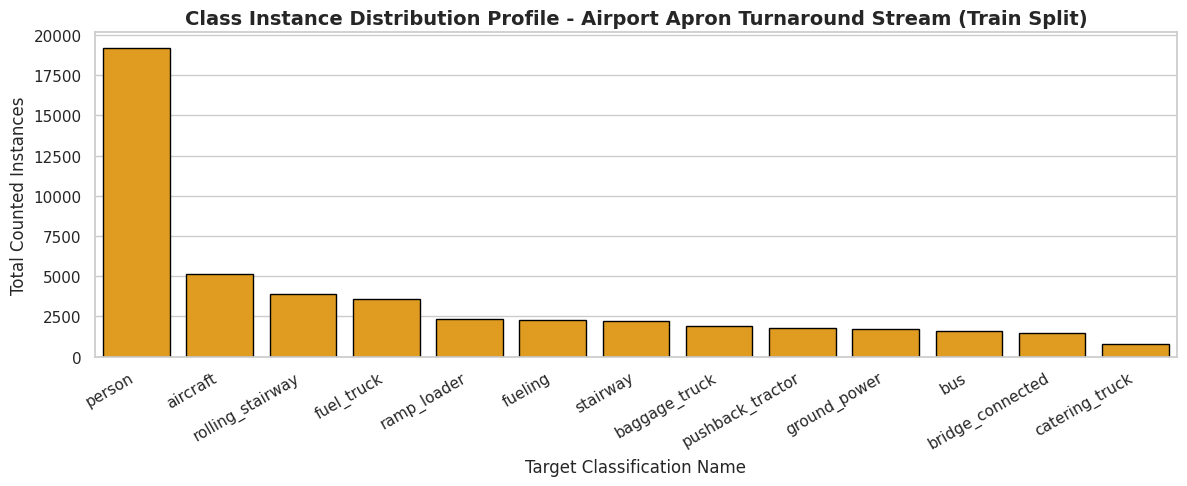

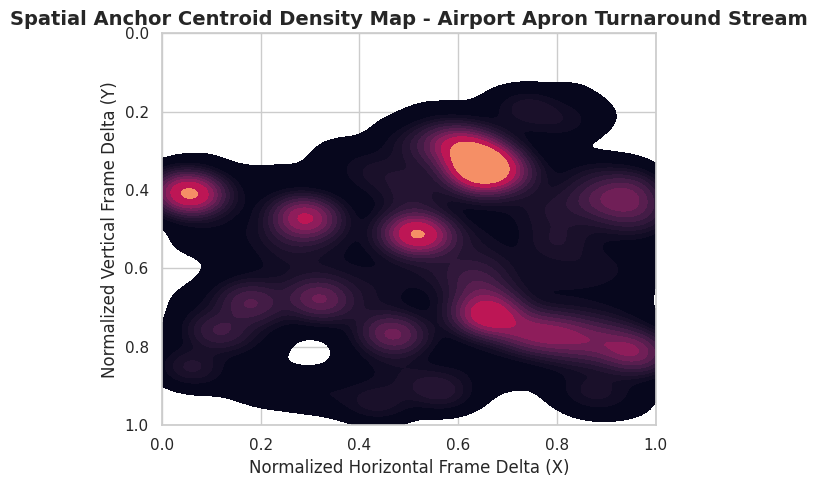

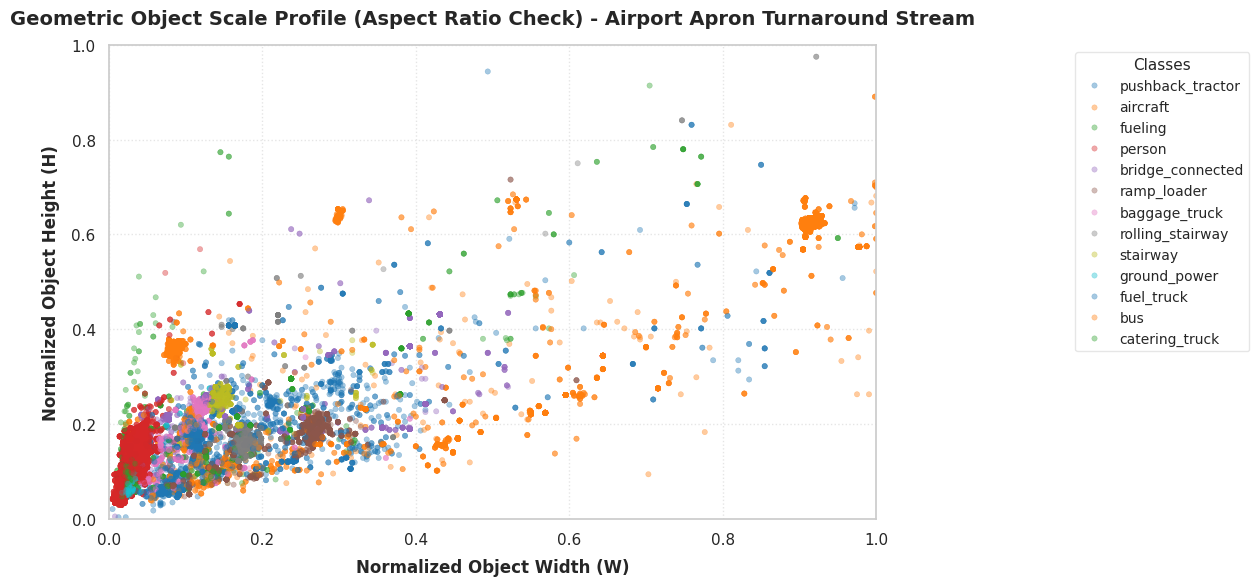


🔍 INSIGHT SUMMARY FOR AIRPORT APRON TURNAROUND STREAM:
    - Average Scene Congestion Density: 5.83 objects per frame.
    - Mean Object Spatial Footprint: 0.8955% of image total frame canvas area.
    - Max Aspect Ratio Skew: 7.50 (Extreme wide bounding width).

📊 STARTING IN-DEPTH EDA FOR GROUND WORKER PPE SAFETY STREAM

📈 DATASET SPLIT INFRASTRUCTURE PROFILE:
Split  Image Count  Total Bounding Boxes
Train         9856                 34501
  Val          786                  1977
 Test          664                  1606


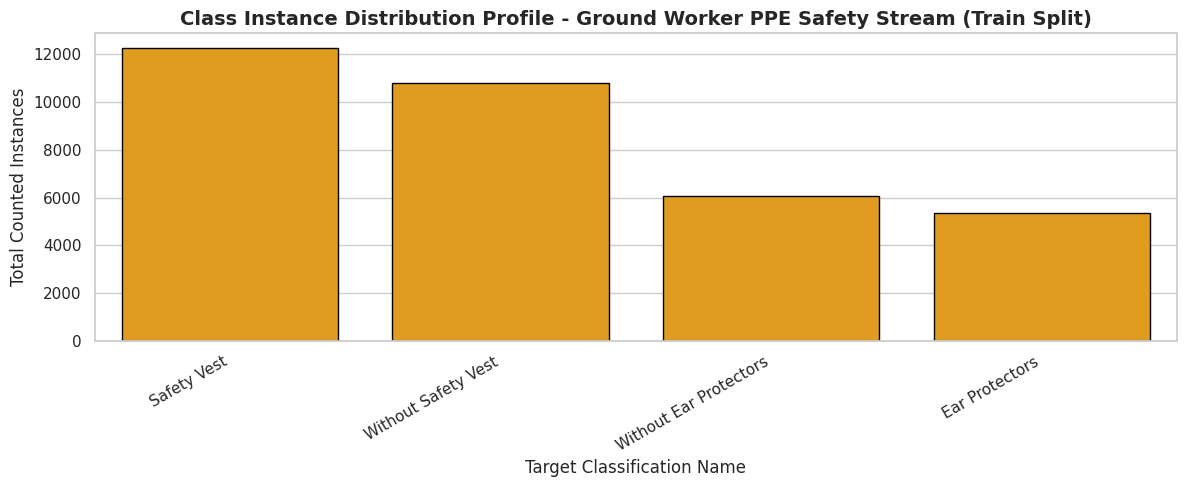

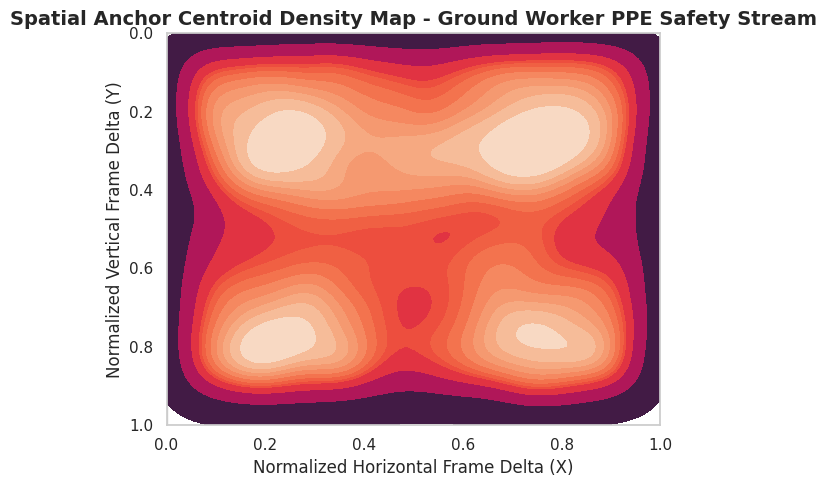

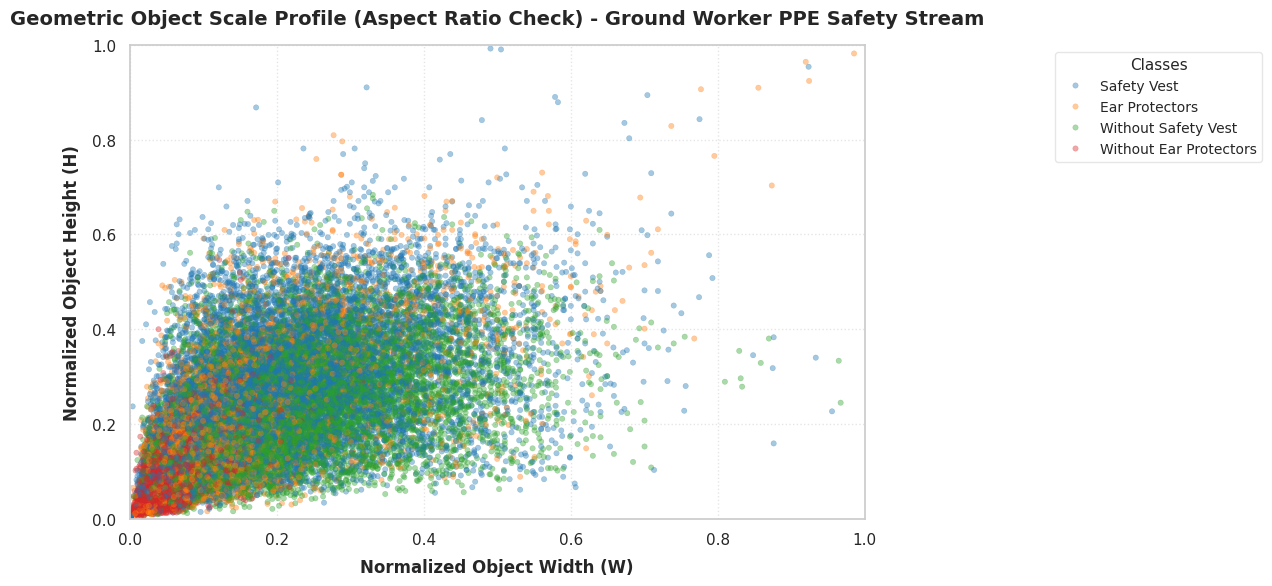


🔍 INSIGHT SUMMARY FOR GROUND WORKER PPE SAFETY STREAM:
    - Average Scene Congestion Density: 3.50 objects per frame.
    - Mean Object Spatial Footprint: 2.6184% of image total frame canvas area.
    - Max Aspect Ratio Skew: 9.31 (Extreme wide bounding width).

📊 STARTING IN-DEPTH EDA FOR AIRPORT APRON FOREIGN OBJECT DEBRIS (FOD) STREAM

📈 DATASET SPLIT INFRASTRUCTURE PROFILE:
Split  Image Count  Total Bounding Boxes
Train        33730                 34405
  Val        11640                 11879
 Test        11620                 11834


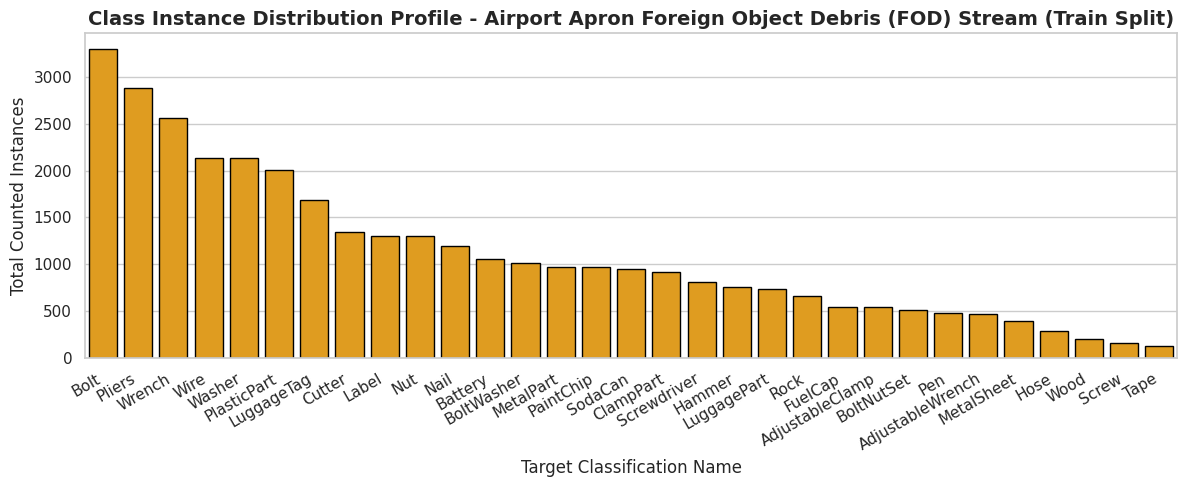

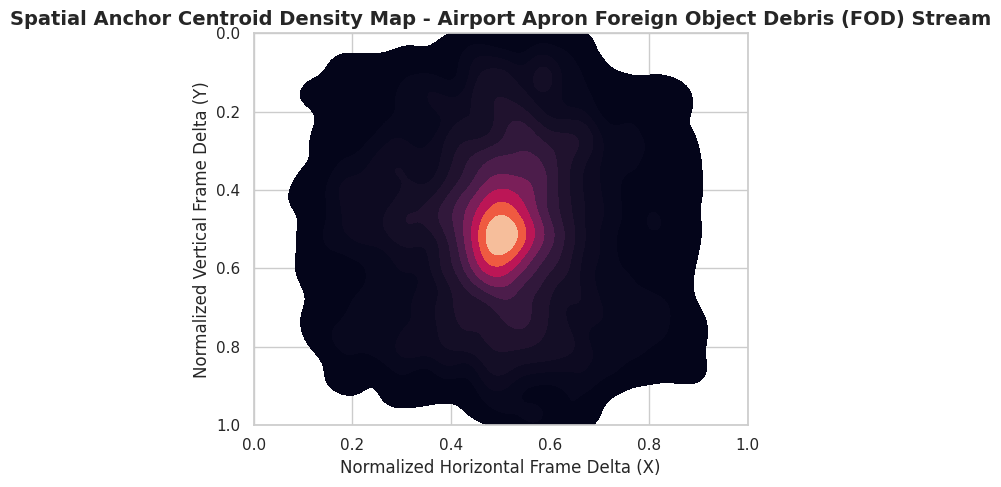

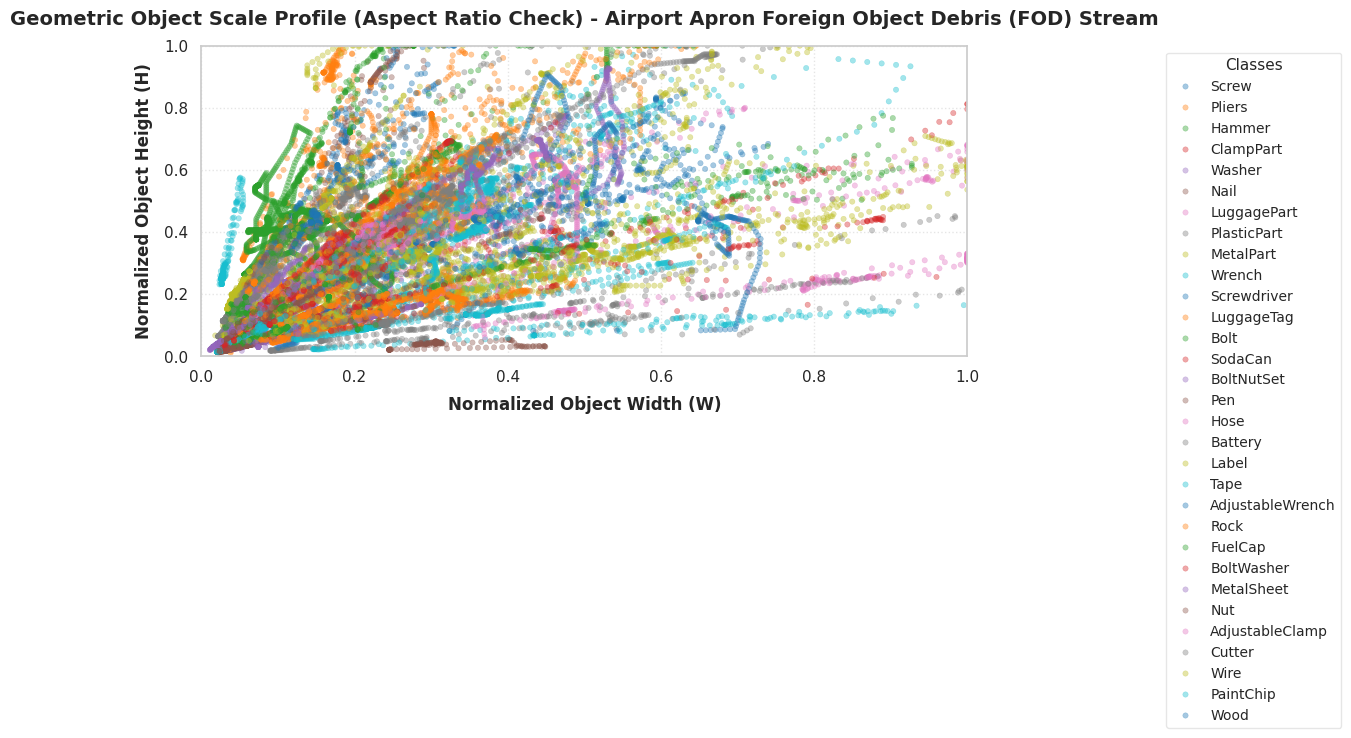


🔍 INSIGHT SUMMARY FOR AIRPORT APRON FOREIGN OBJECT DEBRIS (FOD) STREAM:
    - Average Scene Congestion Density: 1.02 objects per frame.
    - Mean Object Spatial Footprint: 3.6123% of image total frame canvas area.
    - Max Aspect Ratio Skew: 14.14 (Extreme wide bounding width).



In [6]:
# ------------------------------------
# 4. Streamlined Dynamic EDA Dashboard
# ------------------------------------
from data_preparation.yaml_reader import get_metadata_from_yaml
from data_preparation.eda_pipeline import analyze_dataset_stream

yaml_manifest = {
    "turnaround_data.yaml": "Airport Apron Turnaround Stream",
    "ppe_data.yaml": "Ground Worker PPE Safety Stream",
    "fod_data.yaml": "Airport Apron Foreign Object Debris (FOD) Stream"
}

for yaml_filename, stream_display_name in yaml_manifest.items():
    yaml_file_path = CONFIG_DIR / yaml_filename

    if not yaml_file_path.exists():
        print(f"⚠️ Configuration file missing at {yaml_file_path}")
        continue

    # print(f"📖 Parsing metadata configurations dynamically from: {yaml_filename}")

    # 1. Dynamically extract classes straight from the source file
    dynamic_classes = get_metadata_from_yaml(yaml_file_path)

    # 2. Automatically locate the target stream's data directory inside the YAML config
    with open(yaml_file_path, 'r') as f:
        stream_root_directory = yaml.safe_load(f).get('path')

    # 3. Trigger the full structural analysis suite using the parsed data
    analyze_dataset_stream(
        stream_path=stream_root_directory,
        stream_name=stream_display_name,
        class_names=dynamic_classes,
        base_path=BASE_DIR,
    )